# Testing analysis

## 1. Direct

### Accuracy

In [10]:
import json

with open("predictions.json", 'r', encoding='utf-8') as f:
    data = json.load(f)["data"]

data = [d for d in data]

total = len(data)
correct = 0

for d in data:
    if d["predict"] == d["label"]: correct += 1

print("Accuracy:", correct / total)

Accuracy: 0.3805774278215223


### Confusion matrix

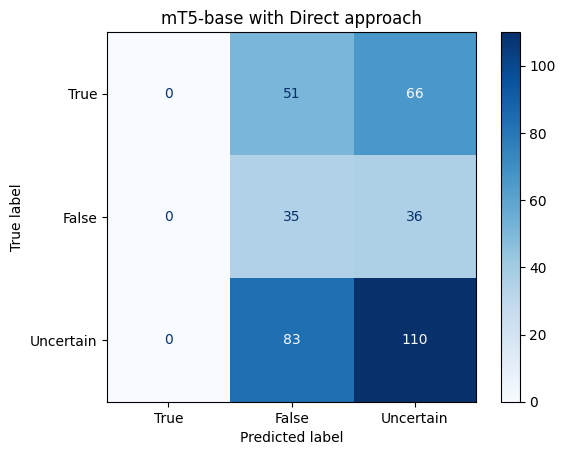

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

with open("predictions.json", 'r', encoding='utf-8') as f:
    data = json.load(f)["data"]

y_pred = [d["predict"] for d in data]
y_true = [d["label"] for d in data]

classes = ["True", "False", "Uncertain"]
cm = confusion_matrix(y_true, y_pred, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("mT5-base with Direct approach")
plt.show()

## 2. FOL-related 

### Accuracy

In [18]:
import json

with open("predictions.json", 'r', encoding='utf-8') as f:
    data = json.load(f)["data"]

wrong_data = []; correct_data = []

total = len(data)
correct = 0
empty = 0

T = len([d for d in data if d["label"] == "True"])
F = len([d for d in data if d["label"] == "False"])
U = len([d for d in data if d["label"] == "Uncertain"])
u = 0; t = 0; f = 0
count_pred_labels = {
    "True": 0,
    "False":0,
    "Uncertain": 0
}
preds = []

for d in data:
    true_label = d["label"]
    pred_labels = [p["label"] for p in d["predictions"]]
    pred_final_label = '.'

    if (len(pred_labels)):
        pred_final_label = max(pred_labels, key=pred_labels.count)
        count_pred_labels[pred_final_label] += 1

        if (pred_final_label == true_label):
            correct += 1
            
            # count Uncertain correct
            if (true_label == "Uncertain"): u += 1
            if (true_label == "True"): t += 1
            if (true_label == "False"): f += 1

            if (true_label in ['Uncertain']): correct_data.append(d)

        else: 
            wrong_data.append(d)
    else:
        empty += 1
        wrong_data.append(d)

    preds.append(pred_final_label)
    
print("Total samples:", total)
print("Accuracy: ", correct / total)
print("Empty ratio: ", empty / total)
# print("Correct ratios:", t / T, f / F, u / U)
# print(f"{u}/{U}, {t}/{T}, {f}/{F}")

print("Correct ratio:")
print(f"  - True: {t}/{T} = {t/T}")
print(f"  - False: {f}/{F} = {f/F}")
print(f"  - True: {u}/{U} = {u/U}")

print("Predictions count:", count_pred_labels)

with open('wrong_preds.json', 'w', encoding='utf-8') as f:
    json.dump(wrong_data, f, indent=4, ensure_ascii=False)

with open('correct_preds.json', 'w', encoding='utf-8') as f:
    json.dump(correct_data, f, indent=4, ensure_ascii=False)

Total samples: 200
Accuracy:  0.725
Empty ratio:  0.0
Correct ratio:
  - True: 35/62 = 0.5645161290322581
  - False: 41/61 = 0.6721311475409836
  - True: 69/77 = 0.8961038961038961
Predictions count: {'True': 43, 'False': 46, 'Uncertain': 111}


### Confusion matrix

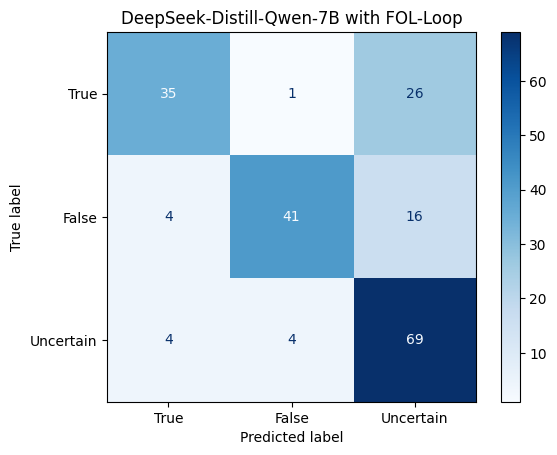

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classes = ["True", "False", "Uncertain"]

y_true = [d["label"] for d in data]
y_pred = preds

# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("DeepSeek-Distill-Qwen-7B with FOL-Loop")
plt.show()

# Training analysis

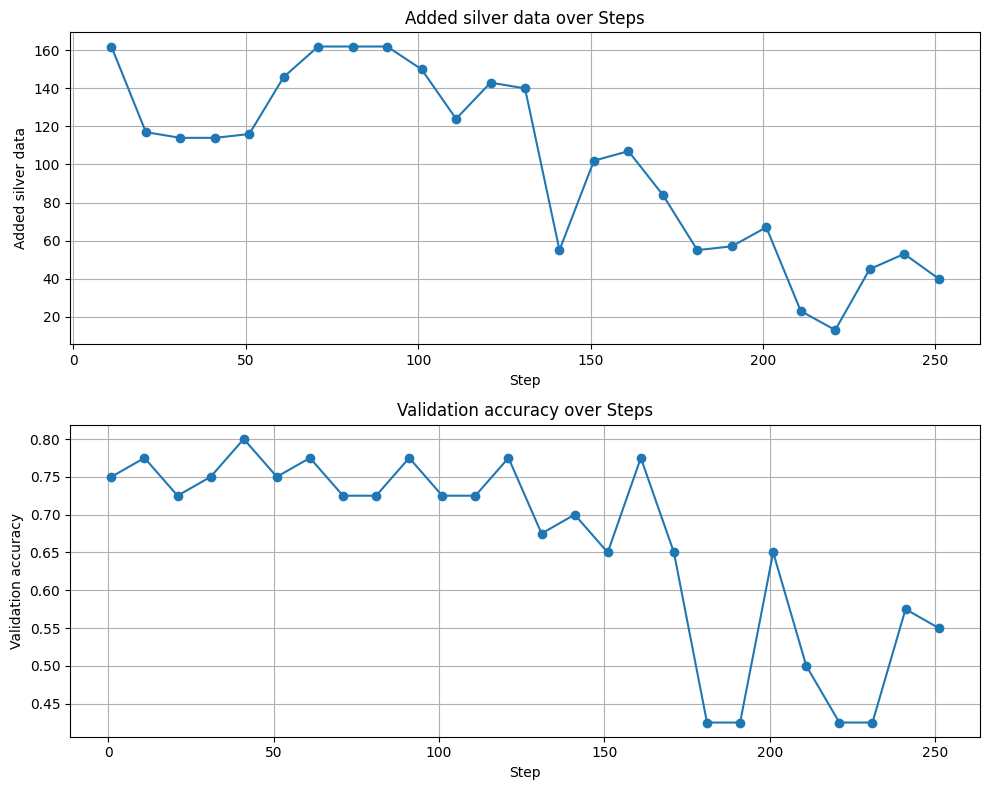

In [13]:
import matplotlib.pyplot as plt

steps = [
    1, 11, 21, 31, 41, 51, 61, 71, 81, 91,
    101, 111, 121, 131, 141, 151, 161,
    171, 181, 191, 201, 211, 221, 231, 241, 251
]

valid_acc = [
    0.75, 0.775, 0.725, 0.75, 0.8,
    0.75, 0.775, 0.725, 0.725, 0.775,
    0.725, 0.725, 0.775, 0.675, 0.7,
    0.65, 0.775,
    0.65, 0.425, 0.425, 0.65, 0.5,
    0.425, 0.425, 0.575, 0.55
]

add_silver_data = [
    162, 117, 114, 114, 116, 146, 162,
    162, 162, 150, 124, 143, 140, 55,
    102, 107, 84, 55, 57, 67, 23,
    13, 45, 53, 40
]

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(steps[1:], add_silver_data, marker='o')
plt.xlabel("Step")
plt.ylabel("Added silver data")
plt.title("Added silver data over Steps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(steps, valid_acc, marker='o')
plt.xlabel("Step")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy over Steps")
plt.grid(True)

plt.tight_layout()
plt.show()